In [1]:
from config import METHOD_MI_KSG
%reload_ext autoreload
%autoreload 2

In [28]:
from scripts import _1_load_full_dataset
from scripts import _2_create_subsample_datasets
from scripts import _3_split_dataset
from scripts import _4_feature_selection
from scripts import _5_scoring

from src import config

from src.persistence import ground_truth as ground_truth_persistence
from src.measures.benchmarking import driver_recovery_metric


SUBSAMPLE_SIZE = 25_000
TEST_SPLIT_SIZE = 40

In [ ]:
_1_load_full_dataset.main()

In [16]:
_2_create_subsample_datasets.main(subsample_size=SUBSAMPLE_SIZE)

2026-07-06 08:55:29 [INFO] (datasets.py) Load or create dataset: subsample size=25000, level=celltype.l2
2026-07-06 08:55:29 [INFO] (datasets.py) Creating subsample dataset: (subsample size=25000, level=celltype.l2)
2026-07-06 08:55:29 [INFO] (datasets.py) Load or create dataset full dataset from raw MatrixMarket files
2026-07-06 08:55:29 [INFO] (datasets.py) Dataset exists: /Users/inbad/.data_science_project/data/processed_data/full_datasets/celltype.l2/multi_modal_dataset.h5mu
2026-07-06 08:55:29 [INFO] (datasets.py) Skipping creation [force_recreate=False]


In [18]:
_3_split_dataset.main(subsample_size=SUBSAMPLE_SIZE,
                      test_split_size=TEST_SPLIT_SIZE)

2026-07-06 08:55:57 [INFO] (datasets.py) Load or create dataset: subsample size=25000, level=celltype.l2
2026-07-06 08:55:57 [INFO] (datasets.py) Dataset exists: /Users/inbad/.data_science_project/data/processed_data/subsampled_datasets/celltype.l2/subsample_25000_seed_42/multi_modal_dataset.h5mu
2026-07-06 08:55:57 [INFO] (datasets.py) Skipping creation [force_recreate=False]
2026-07-06 08:56:00 [INFO] (_3_split_dataset.py) Filtering...
2026-07-06 08:56:02 [INFO] (_3_split_dataset.py) ['ASDC' 'B intermediate' 'B memory' 'B naive' 'CD14 Mono' 'CD16 Mono'
 'CD4 CTL' 'CD4 Naive' 'CD4 Proliferating' 'CD4 TCM' 'CD4 TEM' 'CD8 Naive'
 'CD8 Proliferating' 'CD8 TCM' 'CD8 TEM' 'Eryth' 'HSPC' 'ILC' 'MAIT' 'NK'
 'NK Proliferating' 'NK_CD56bright' 'Plasmablast' 'Platelet' 'Treg' 'cDC1'
 'cDC2' 'dnT' 'gdT' 'pDC']
2026-07-06 08:56:02 [INFO] (_3_split_dataset.py) ['ASDC' 'B intermediate' 'B memory' 'B naive' 'CD14 Mono' 'CD16 Mono'
 'CD4 CTL' 'CD4 Naive' 'CD4 Proliferating' 'CD4 TCM' 'CD4 TEM' 'CD8 N

In [19]:
_4_feature_selection.main(subsample_size=SUBSAMPLE_SIZE,
                          test_split_size=TEST_SPLIT_SIZE)

2026-07-06 08:56:10 [INFO] (splits.py) Persist data split to disk:
2026-07-06 08:56:10 [INFO] (splits.py)   split_name: hvg_split
2026-07-06 08:56:10 [INFO] (splits.py)   training/test: 40/60
2026-07-06 08:56:10 [INFO] (splits.py)   seed: 42
2026-07-06 08:56:10 [INFO] (splits.py)   subsample_size: 25000
2026-07-06 08:56:10 [INFO] (splits.py)   level: celltype.l2
2026-07-06 08:56:10 [INFO] (splits.py) Training data file: /Users/inbad/.data_science_project/persistence/data_splits/celltype.l2/subsample_25000_split_40_seed_42/hvg_split/training.h5mu
2026-07-06 08:56:11 [INFO] (splits.py) Test data file: /Users/inbad/.data_science_project/persistence/data_splits/celltype.l2/subsample_25000_split_40_seed_42/hvg_split/test.h5mu


In [20]:
_5_scoring.main(method=config.METHOD_MI_KSG,
                subsample_size=SUBSAMPLE_SIZE,
                test_split_size=TEST_SPLIT_SIZE)

2026-07-06 08:56:18 [INFO] (_5_scoring.py) Loading split data...
2026-07-06 08:56:18 [INFO] (_5_scoring.py) 
2026-07-06 08:56:18 [INFO] (_5_scoring.py) Training data (RNA modality):
2026-07-06 08:56:18 [INFO] (_5_scoring.py) -----------------------------
2026-07-06 08:56:18 [INFO] (_5_scoring.py)   n_cells (rows): 14841
2026-07-06 08:56:18 [INFO] (_5_scoring.py)   n_genes (cols): 2039
2026-07-06 08:56:18 [INFO] (_5_scoring.py) 
2026-07-06 08:56:18 [INFO] (_5_scoring.py) Test data (RNA modality):
2026-07-06 08:56:18 [INFO] (_5_scoring.py) -----------------------------
2026-07-06 08:56:18 [INFO] (_5_scoring.py)   n_cells (rows): 9894
2026-07-06 08:56:18 [INFO] (_5_scoring.py)   n_genes (cols): 2039
2026-07-06 08:56:18 [INFO] (_5_scoring.py) 
2026-07-06 08:56:19 [INFO] (mutual_information_ksg.py) Computing Non-Linear/marginal scoring: Mutual Information (KSG)
2026-07-06 08:59:24 [INFO] (_5_scoring.py) Done.


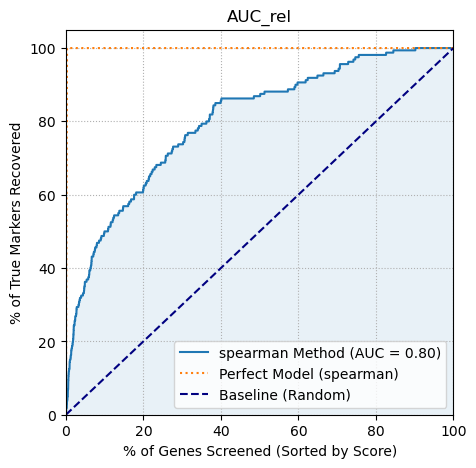

In [31]:
# Example: loading results

from persistence import scoring_results as results_persistence

mi_results = results_persistence.load_results(
    method=METHOD_MI_KSG,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
    root_dir=config.LOCAL_RESULTS_ROOT / "mi_25_000"
)

driver_gene_ground_truth = ground_truth_persistence.load_ground_truth(
    root_dir=config.LOCAL_DATA_ROOT,
    test_split_size=TEST_SPLIT_SIZE)

results = [mi_results]

driver_recovery_metric.plot(results,
                            config.METHODS,
                            driver_gene_ground_truth)